In [1]:
import functools
import matplotlib.pyplot as plt
import numpy as np
import torch
import seaborn as sns

from network import Net, NetDiscovery
from diff_equations import grad, cooling_law

sns.set_theme()
torch.manual_seed(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if torch.cuda.is_available():
    device = torch.device('cuda')
    torch.backends.cudnn.benchmark = True
else:
    device = torch.device('cpu')

if torch.cuda.is_available():
    torch.empty(1).to(DEVICE)

print(f"PyTorch will use: {DEVICE}")

PyTorch will use: cuda


# Parameters

In [ ]:
number_of_points = 10
noise_coeff = 2

pinn_collocation_points = 1000
parameter_discovery_collocation_points = 1000

pinn_loss2_weight = 1
parameter_discovery_loss_2_weight = 1

pinn_epochs = 30000
parameter_discovery_epochs = 40000

Text(0.5, 0, 'Time (s)')

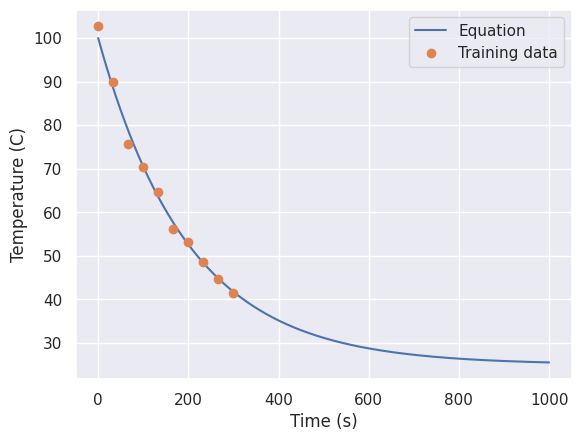

In [3]:
np.random.seed(10)

Tenv = 25
T0 = 100
R = 0.005


times = np.linspace(0, 1000, 1000)
eq = functools.partial(cooling_law, Tenv=Tenv, T0=T0, R=R)
temps = eq(times)

# Make training data
t = np.linspace(0, 300, number_of_points)
T = eq(t) + noise_coeff * np.random.randn(number_of_points)

plt.plot(times, temps)
plt.plot(t, T, 'o')
plt.legend(['Equation', 'Training data'])
plt.ylabel('Temperature (C)')
plt.xlabel('Time (s)')

# PINN

In [4]:
def physics_loss(model: torch.nn.Module, n_points=pinn_collocation_points):
    ts = torch.linspace(0, 1000, steps=n_points).view(-1,1).requires_grad_(True).to(DEVICE)
    temps = model(ts)
    dT = grad(temps, ts)[0]
    pde = R*(Tenv - temps) - dT

    return torch.mean(pde**2)

/home/reza/miniconda3/envs/pinns/lib/python3.10/site-packages/torch/autograd/graph.py:869: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:335.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch 0/30000, loss: 4713.90
Epoch 3000/30000, loss: 2462.07
Epoch 6000/30000, loss: 808.88
Epoch 9000/30000, loss: 2.87
Epoch 12000/30000, loss: 0.44
Epoch 15000/30000, loss: 0.38
Epoch 18000/30000, loss: 0.38
Epoch 21000/30000, loss: 0.30
Epoch 24000/30000, loss: 0.26
Epoch 27000/30000, loss: 0.25


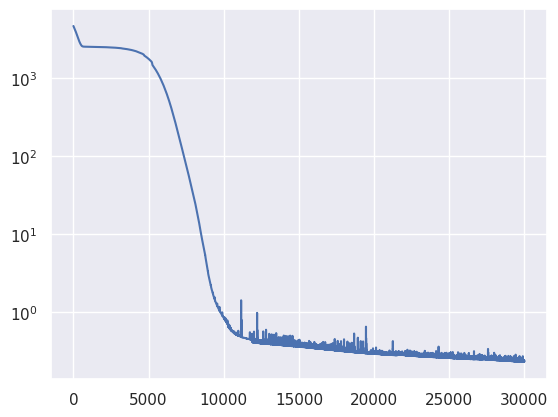

In [5]:
net = Net(1,1, loss2=physics_loss, epochs=pinn_epochs, loss2_weight=pinn_loss2_weight, lr=1e-5).to(DEVICE)

losses = net.fit(t, T)
plt.plot(losses)
plt.yscale('log')

Text(0.5, 0, 'Time (s)')

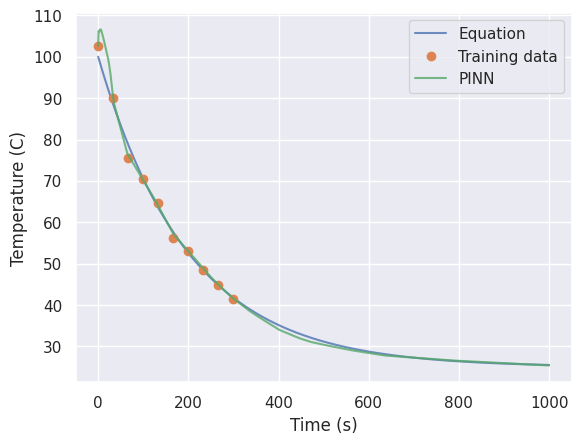

In [6]:
preds = net.predict(times)

plt.plot(times, temps, alpha=0.8)
plt.plot(t, T, 'o')
plt.plot(times, preds, alpha=0.8)
plt.legend(labels=['Equation','Training data', 'PINN'])
plt.ylabel('Temperature (C)')
plt.xlabel('Time (s)')

# Parameter discovery

In [7]:
def physics_loss_discovery(model: torch.nn.Module, n_points=parameter_discovery_collocation_points):

    ts = torch.linspace(0, 1000, steps=n_points).view(-1,1).requires_grad_(True).to(DEVICE)

    temps = model(ts)
    dT = grad(temps, ts)[0]
    pde = model.r * (Tenv - temps) - dT

    return torch.mean(pde**2)

Epoch 0/40000, loss: 4622.79
Epoch 4000/40000, loss: 2482.80
Epoch 8000/40000, loss: 1880.86
Epoch 12000/40000, loss: 139.89
Epoch 16000/40000, loss: 1.07
Epoch 20000/40000, loss: 0.57
Epoch 24000/40000, loss: 0.45
Epoch 28000/40000, loss: 0.34
Epoch 32000/40000, loss: 0.29
Epoch 36000/40000, loss: 0.25


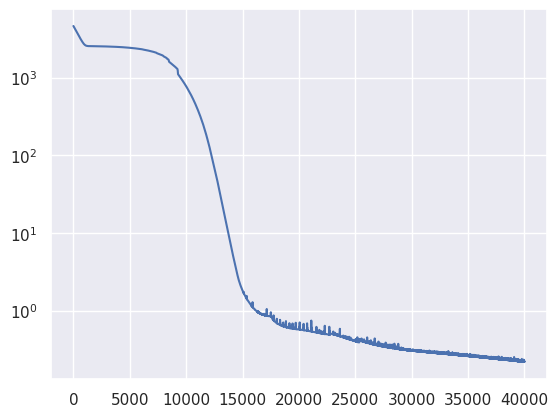

In [8]:
netdisc = NetDiscovery(1, 1, loss2=physics_loss_discovery, loss2_weight=parameter_discovery_loss_2_weight, epochs=parameter_discovery_epochs, lr=5e-6).to(DEVICE)

losses = netdisc.fit(t, T)

plt.plot(losses)
plt.yscale('log')

Parameter containing:
tensor([0.0044], device='cuda:0', requires_grad=True)


Text(0.5, 0, 'Time (s)')

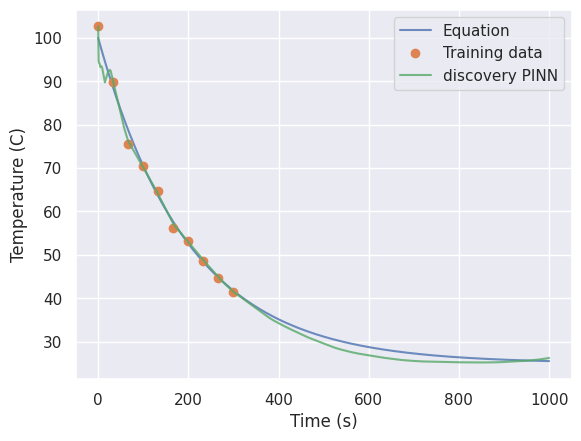

In [9]:
preds = netdisc.predict(times)
print(netdisc.r)

plt.plot(times, temps, alpha=0.8)
plt.plot(t, T, 'o')
plt.plot(times, preds, alpha=0.8)
plt.legend(labels=['Equation','Training data', 'discovery PINN'])
plt.ylabel('Temperature (C)')
plt.xlabel('Time (s)')

# Save Results

In [10]:
import os
import csv
import datetime
from pathlib import Path

# ── Folder structure ──────────────────────────────────────────────────────────
RESULTS_DIR = Path('results')
ASSETS_DIR  = RESULTS_DIR / 'assets'
CSV_PATH    = RESULTS_DIR / 'experiments.csv'

RESULTS_DIR.mkdir(exist_ok=True)
ASSETS_DIR.mkdir(exist_ok=True)

# ── Experiment ID ─────────────────────────────────────────────────────────────
# Auto-increment based on existing rows in the CSV
def next_exp_id(csv_path):
    if not csv_path.exists():
        return 'exp1'
    with open(csv_path, newline='') as f:
        rows = list(csv.DictReader(f))
    return f'exp{len(rows) + 1}'

exp_id = next_exp_id(CSV_PATH)
exp_dir = ASSETS_DIR / exp_id
exp_dir.mkdir(exist_ok=True)

print(f'Experiment ID: {exp_id}')
print(f'Saving assets to: {exp_dir}')


Experiment ID: exp1
Saving assets to: results/assets/exp1


In [11]:
# ── Save plots ────────────────────────────────────────────────────────────────

# 1. PINN training loss
fig, ax = plt.subplots()
ax.plot(losses)
ax.set_yscale('log')
ax.set_title('PINN training loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
fig.savefig(exp_dir / 'pinn_loss.jpg', dpi=100, bbox_inches='tight')
plt.close(fig)

# 2. PINN prediction
preds_pinn = net.predict(times)
fig, ax = plt.subplots()
ax.plot(times, temps, alpha=0.8)
ax.plot(t, T, 'o', ms=3, alpha=0.5)
ax.plot(times, preds_pinn, alpha=0.8)
ax.legend(['Equation', 'Training data', 'PINN'])
ax.set_ylabel('Temperature (C)')
ax.set_xlabel('Time (s)')
ax.set_title('PINN prediction')
fig.savefig(exp_dir / 'pinn_prediction.jpg', dpi=100, bbox_inches='tight')
plt.close(fig)

# 3. Parameter discovery training loss
fig, ax = plt.subplots()
ax.plot(losses)
ax.set_yscale('log')
ax.set_title('Parameter discovery training loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
fig.savefig(exp_dir / 'pd_loss.jpg', dpi=100, bbox_inches='tight')
plt.close(fig)

# 4. Parameter discovery prediction
preds_disc = netdisc.predict(times)
fig, ax = plt.subplots()
ax.plot(times, temps, alpha=0.8)
ax.plot(t, T, 'o', ms=3, alpha=0.5)
ax.plot(times, preds_disc, alpha=0.8)
ax.legend(['Equation', 'Training data', 'Discovery PINN'])
ax.set_ylabel('Temperature (C)')
ax.set_xlabel('Time (s)')
ax.set_title(f'Parameter discovery  |  R discovered = {float(netdisc.r):.5f}')
fig.savefig(exp_dir / 'pd_prediction.jpg', dpi=100, bbox_inches='tight')
plt.close(fig)

print(f'Saved 4 plots to {exp_dir}')


Saved 4 plots to results/assets/exp1


/tmp/ipykernel_83633/788104642.py:45: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  ax.set_title(f'Parameter discovery  |  R discovered = {float(netdisc.r):.5f}')


In [12]:
# ── Compute accuracy metrics ──────────────────────────────────────────────────
R_discovered   = float(netdisc.r)
R_error_pct    = abs(R_discovered - R) / R * 100
pinn_final_loss = losses[-1]          # last loss from PINN training

# ── Build record ──────────────────────────────────────────────────────────────
record = {
    'exp_id':                                   exp_id,
    'timestamp':                                datetime.datetime.now().isoformat(timespec='seconds'),
    # parameters
    'number_of_points':                         number_of_points,
    'noise_coeff':                              noise_coeff,
    'pinn_collocation_points':                  pinn_collocation_points,
    'parameter_discovery_collocation_points':   parameter_discovery_collocation_points,
    'pinn_loss2_weight':                        pinn_loss2_weight,
    'parameter_discovery_loss_2_weight':        parameter_discovery_loss_2_weight,
    'pinn_epochs':                              pinn_epochs,
    'parameter_discovery_epochs':               parameter_discovery_epochs,
    # results
    'R_true':                                   R,
    'R_discovered':                             R_discovered,
    'R_error_pct':                              round(R_error_pct, 4),
    'pinn_final_loss':                          round(float(pinn_final_loss), 6),
    'assets_folder':                            str(exp_dir),
}

# ── Append to CSV (create with header if first time) ─────────────────────────
write_header = not CSV_PATH.exists()
with open(CSV_PATH, 'a', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=record.keys())
    if write_header:
        writer.writeheader()
    writer.writerow(record)

print(f'Record saved to {CSV_PATH}')
print()
for k, v in record.items():
    print(f'  {k:<48} {v}')


Record saved to results/experiments.csv

  exp_id                                           exp1
  timestamp                                        2026-04-12T10:35:55
  number_of_points                                 10
  noise_coeff                                      2
  pinn_collocation_points                          1000
  parameter_discovery_collocation_points           1000
  pinn_loss2_weight                                1
  parameter_discovery_loss_2_weight                1
  pinn_epochs                                      30000
  parameter_discovery_epochs                       40000
  R_true                                           0.005
  R_discovered                                     0.004404547158628702
  R_error_pct                                      11.9091
  pinn_final_loss                                  0.2232
  assets_folder                                    results/assets/exp1
